SWIGGY SALES ANALYSIS

IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

IMPORT DATA

In [2]:
df = pd.read_excel(r"c:\Users\DELL\Downloads\swiggy_data.xlsx")

In [3]:
df.head(6)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0
5,Karnataka,Bengaluru,2025-07-08,Srinidhi Sagar Deluxe,Kengeri,Recommended,Srinidhi Sagar Special,312.0,4.0,0


In [5]:
df.tail(6)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197424,Sikkim,Gangtok,2025-08-11,Mama's Kitchen,Gangtok,Momos,Soya cheese fried momo ...,98.0,4.4,0
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


METADATA

In [6]:
print("numbers of rows: ",df.shape[0])

numbers of rows:  197430


In [7]:
print("numbers of fields: ",df.shape[1])

numbers of fields:  10


In [8]:
df.info

<bound method DataFrame.info of             State       City Order Date           Restaurant Name  \
0       Karnataka  Bengaluru 2025-06-29  Anand Sweets & Savouries   
1       Karnataka  Bengaluru 2025-04-03     Srinidhi Sagar Deluxe   
2       Karnataka  Bengaluru 2025-01-15     Srinidhi Sagar Deluxe   
3       Karnataka  Bengaluru 2025-04-17     Srinidhi Sagar Deluxe   
4       Karnataka  Bengaluru 2025-03-13     Srinidhi Sagar Deluxe   
...           ...        ...        ...                       ...   
197425     Sikkim    Gangtok 2025-01-25            Mama's Kitchen   
197426     Sikkim    Gangtok 2025-07-02            Mama's Kitchen   
197427     Sikkim    Gangtok 2025-03-25            Mama's Kitchen   
197428     Sikkim    Gangtok 2025-03-26            Mama's Kitchen   
197429     Sikkim    Gangtok 2025-03-27            Mama's Kitchen   

                    Location     Category  \
0       Rajarajeshwari Nagar        Snack   
1                    Kengeri  Recommended   
2   

DATA TYPES

In [9]:
df.dtypes

State                         str
City                          str
Order Date         datetime64[us]
Restaurant Name               str
Location                      str
Category                      str
Dish Name                     str
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [10]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996809,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


KPI's

Total Sales

In [11]:
Total_sales = df["Price (INR)"].sum()
print("Total Sales (INR):",round(Total_sales,2))

Total Sales (INR): 53012505.77


Average Rating

In [12]:
Average_rating = df["Rating"].mean()
print("Average rating :",round(Average_rating,2))

Average rating : 4.34


Average Order Value

In [13]:
Avg_order_value =  df["Price (INR)"].mean()
print("avrage order value:",round(Avg_order_value,2))

avrage order value: 268.51


Rating Count

In [14]:
Ratings_Count = df["Rating Count"].sum()
print("Rating Count:", round(Ratings_Count, 2))

Rating Count: 5591574


Total Orders

In [15]:
Total_ordes = len(df)
print("Total ordes:",round(Total_ordes,2))

Total ordes: 197430


CHART DESIGN

Monthly Sales Trend

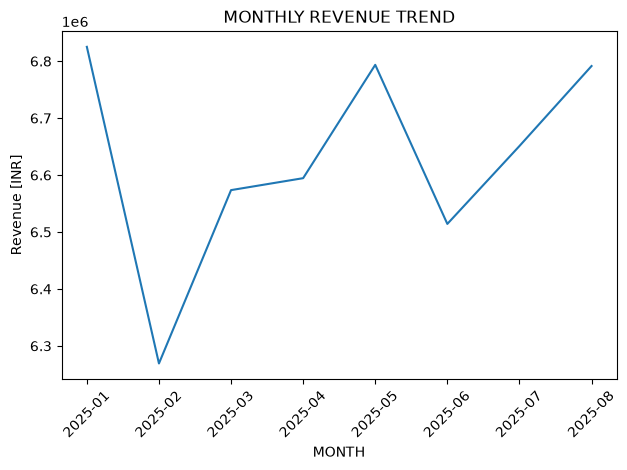

In [16]:
df["Order Date"] = pd. to_datetime(df["Order Date"])

df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_revenue =  df.groupby("YearMonth")["Price (INR)"].sum().reset_index()

plt.figure()
plt.plot(monthly_revenue["YearMonth"],monthly_revenue["Price (INR)"])
plt.xticks(rotation=45)
plt.xlabel("MONTH")
plt.ylabel("Revenue [INR]")
plt.title("MONTHLY REVENUE TREND")
plt.tight_layout()
plt.show()

DAILY SALES TREND

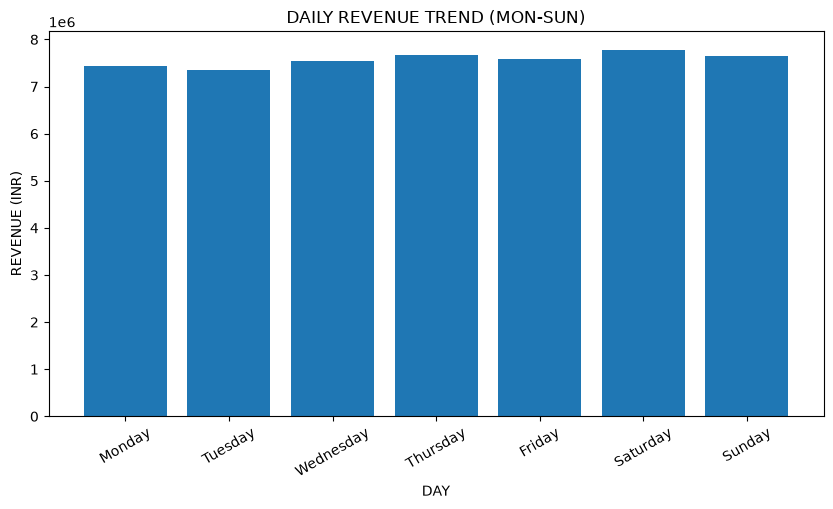

In [17]:
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()


daily_revenue = (
    df.groupby("DayName")["Price (INR)"]
    .sum()
    .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])

)
plt.figure(figsize=(10,5))
plt.bar(daily_revenue.index,daily_revenue.values)
plt.title("DAILY REVENUE TREND (MON-SUN)")
plt.xlabel("DAY")
plt.ylabel("REVENUE (INR)")
plt.xticks(rotation=30)

plt.show()

Total Sales By Food Type (Veg VS Non-Veg)

In [18]:
non_veg_keywords = [
    "chicken", "egg", "fish",
    "mutton", 
    "prawn", "biryani", "kebab",
        "non-veg", "non veg"
]

df["Food Category"] = np.where(
    df["Dish Name"].str.lower().str.contains('|'.join(
        non_veg_keywords), na=False),
        "Non-Veg",
        "Veg"
    
)

In [24]:
food_revenue = df.groupby("Food Category", as_index=False)["Price (INR)"].sum()

In [25]:
fig = px.pie(
    food_revenue,
    values="Price (INR)",
    names="Food Category",
    hole=0.3,
    title="Revenue Contribution: Veg vs Non-Veg"
)

fig.show()

TOTAL SALES BY  STATE

In [28]:
state_revenue = df.groupby("State", as_index=False)["Price (INR)"].sum()
state_revenue = state_revenue.sort_values(by="Price (INR)", ascending=True)

fig = px.bar(
    state_revenue,
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Total Revenue by State",
    text_auto=".2s",
    color="Price (INR)",
    color_continuous_scale="Viridis"
)

fig.update_layout(
    xaxis_title="Total Revenue (INR)",
    yaxis_title="State",
    height=700
)

fig.show()

TOP 5 CITIES BY SALES [INR]

In [30]:
top5_cities = (
    df.groupby("City", as_index=False)["Price (INR)"]
      .sum()
      .sort_values(by="Price (INR)", ascending=False)
      .head(5)
      .sort_values(by="Price (INR)", ascending=True)
)

fig = px.bar(
    top5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities by Sales (INR)",
    text_auto=".2s",
    color="Price (INR)",
    color_continuous_scale="Viridis"
)

fig.update_layout(
    xaxis_title="Total Sales (INR)",
    yaxis_title="City",
    height=500
)

fig.show()

TOP 5 MOST OREDERS DISHES

In [32]:

top5_dishes = (
    df.groupby("Dish Name")
      .size()
      .reset_index(name="Total Orders")
      .sort_values(by="Total Orders", ascending=False)
      .head(5)
      .sort_values(by="Total Orders", ascending=True)
)


fig = px.bar(
    top5_dishes,
    x="Total Orders",
    y="Dish Name",
    orientation="h",
    title="Top 5 Most Ordered Dishes",
    text_auto=True,
    color="Total Orders",
    color_continuous_scale="Viridis"
)

fig.update_layout(
    xaxis_title="Number of Orders",
    yaxis_title="Dish Name",
    height=500
)

fig.show()

TOP 10 RESTAURANTS BY REVENUE

In [35]:

top10_restaurants = (
    df.groupby("Restaurant Name", as_index=False)["Price (INR)"]
      .sum()
      .sort_values(by="Price (INR)", ascending=False)
      .head(10)
      .sort_values(by="Price (INR)", ascending=True)
)

fig = px.bar(
    top10_restaurants,
    x="Price (INR)",
    y="Restaurant Name",
    orientation="h",
    title="Top 10 Restaurants by Revenue",
    text_auto=".2s",
    color="Price (INR)",
    color_continuous_scale="Viridis"
)

fig.update_layout(
    xaxis_title="Total Revenue (INR)",
    yaxis_title="Restaurant Name",
    height=600,
    margin=dict(t=60, b=50, l=150, r=20)
)

fig.show()